In [17]:

import h5py
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

h5_path = Path("/ceph/srv/dwong/training_samples_h5/ER/ER_traces_energy_500_batch_0240.h5")

with h5py.File(h5_path, "r") as f:
    print("file attrs:", dict(f.attrs))
    traces_ds = f["traces"]      # dataset: (batch_size, n_channels, trace_samples), float16
    events_ds = f["events"]      # structured array with x/y/z/energy/type_recoil/no_noise/quantize

    print("traces shape:", traces_ds.shape, "dtype:", traces_ds.dtype)
    print("traces attrs:", dict(traces_ds.attrs))
    print("events dtype names:", events_ds.dtype.names)
    print("events attrs:", dict(events_ds.attrs))

    # pull one event
    i = 0
    trace_i = traces_ds[i]       # numpy array (n_channels, trace_samples)
    meta_i = events_ds[i]        # structured record
    first_trace = trace_i

    # keep a modest in-memory subset for downstream experiments
    traces = traces_ds[:32, :16, :8192].astype(np.float32)
    events = events_ds[:32]

# decode bytes to str for display
meta_dict = {}
for name in events.dtype.names:
    val = meta_i[name]
    if isinstance(val, (bytes, bytearray)):
        val = val.decode("utf-8")
    meta_dict[name] = val
print("first event meta:", meta_dict)
print("type_recoil str:", meta_dict.get("type_recoil"))

print("first_trace shape:", first_trace.shape)


file attrs: {}
traces shape: (100, 56, 65536) dtype: float16
traces attrs: {}
events dtype names: ('x', 'y', 'z', 'energy', 'type_recoil', 'no_noise', 'quantize')
events attrs: {}
first event meta: {'x': np.float64(108.54813723454457), 'y': np.float64(33.46085755639923), 'z': np.float64(-1703.767603743275), 'energy': np.float64(500.0), 'type_recoil': 'ER', 'no_noise': np.False_, 'quantize': np.True_}
type_recoil str: ER
first_trace shape: (56, 65536)


In [18]:
def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))

    for i in range(num_channels):
        color = 'orange' if i > 19 else 'tab:blue'
        plt.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])  # Hide y-axis ticks

    plt.tight_layout()
    plt.show()

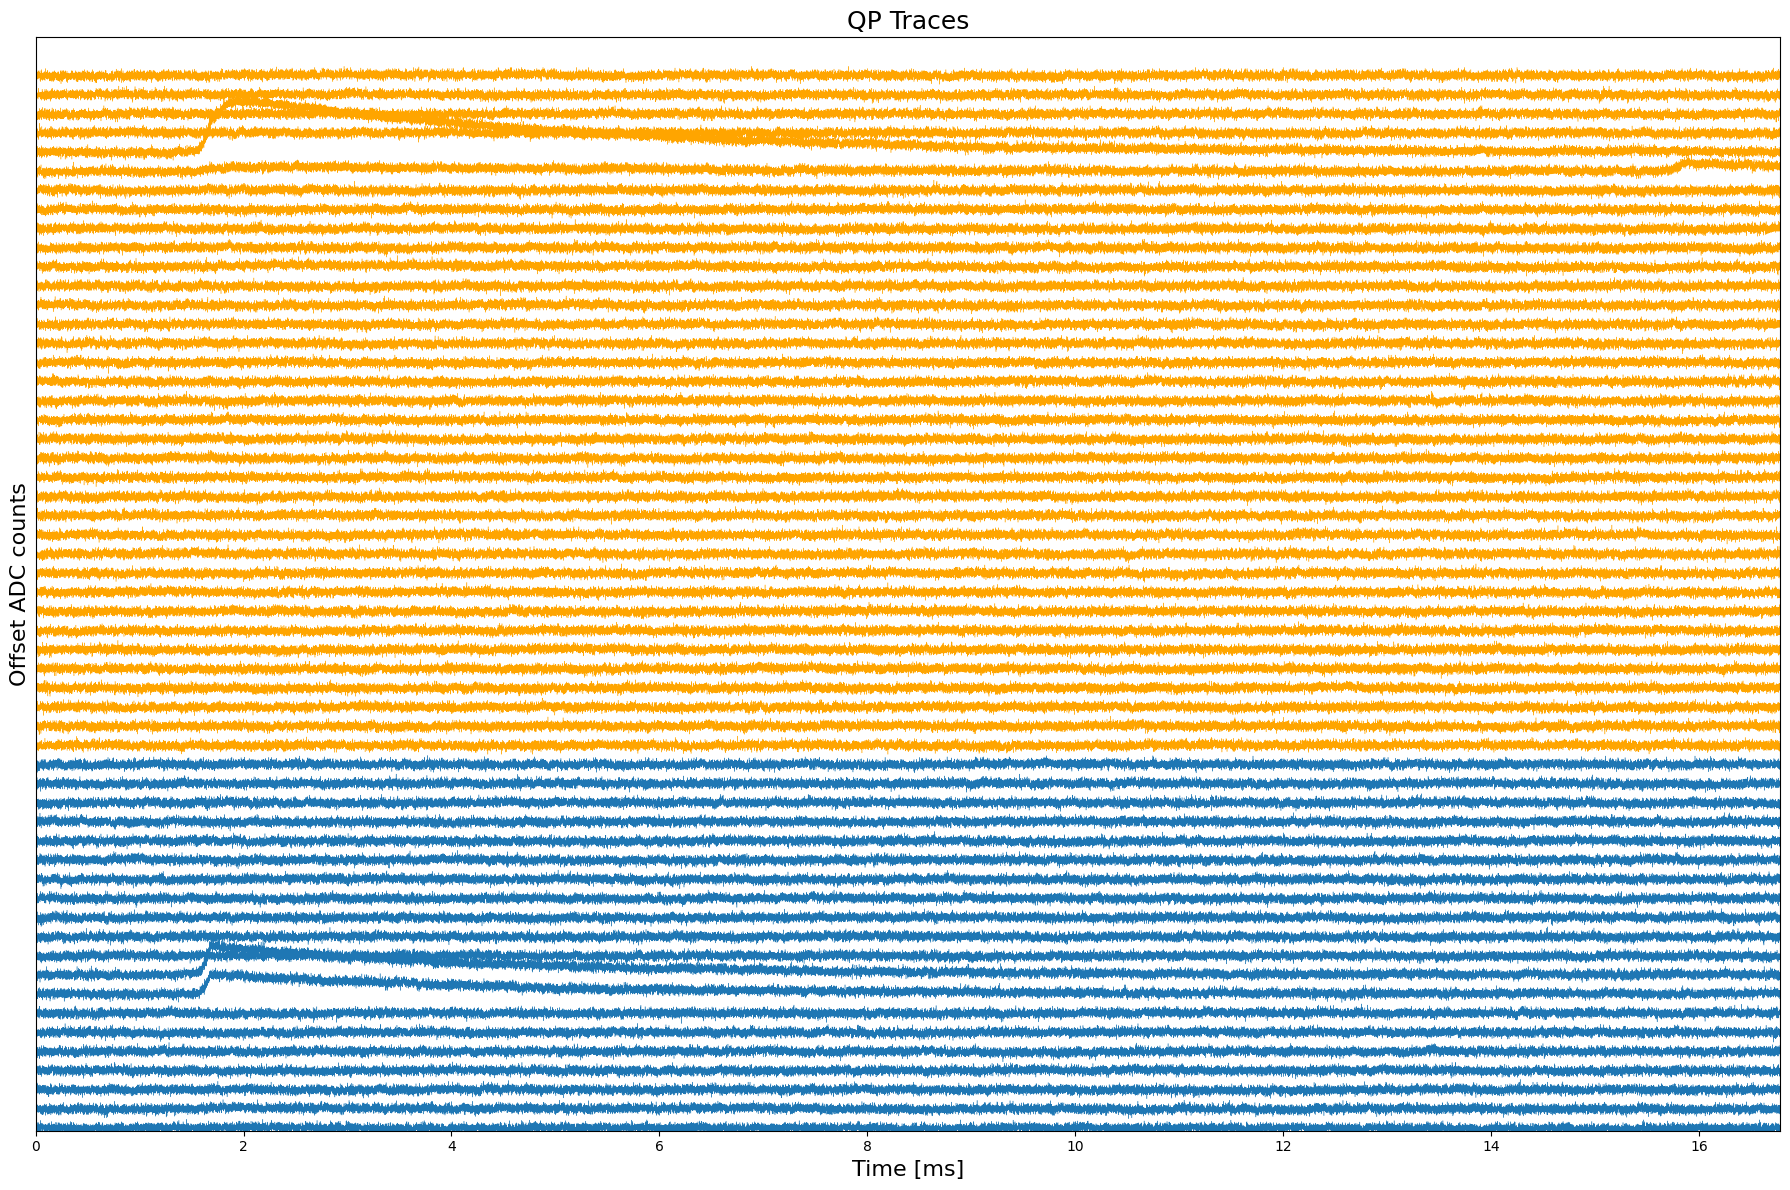

In [19]:
plot_traces(first_trace)

In [20]:
# Quick smoke test for denoiser module on a small subset
from denoiser import (
    CNNDenoiser1D,
    fit_pca,
    pca_denoise,
    run_cnn_denoise,
    train_cnn_denoiser,
)

# take a modest slice to keep runtime manageable
sample = np.asarray(traces[:8, :8, :4096], dtype=np.float32)
print("sample batch/chan/len:", sample.shape)

# PCA round-trip
pca = fit_pca(sample, n_components=5)
pca_recon, pca_coeffs = pca_denoise(pca, sample)
print("PCA recon shape:", pca_recon.shape, "coeffs:", pca_coeffs.shape)
print("PCA MSE:", float(np.mean((pca_recon - sample) ** 2)))

# CNN round-trip (very short training just to exercise the code path)
noisy_sample = sample + 0.05 * np.random.standard_normal(sample.shape).astype(np.float32)
model = train_cnn_denoiser(noisy_sample, sample, num_epochs=1, batch_size=2, device="cpu")
cnn_recon = run_cnn_denoise(model, noisy_sample, batch_size=2, device="cpu")
print("CNN recon shape:", cnn_recon.shape)
print("CNN MSE:", float(np.mean((cnn_recon - sample) ** 2)))


sample batch/chan/len: (8, 8, 4096)
PCA recon shape: (8, 8, 4096) coeffs: (8, 5)
PCA MSE: 14.452908515930176
Epoch 1/1  Loss: 1.0166e+00
CNN recon shape: (8, 8, 4096)
CNN MSE: 59.891014099121094


full trace shape: (56, 65536)
train subset shape: (16, 56, 65536)
Epoch 1/2  Loss: 1.0439e+00
Epoch 2/2  Loss: 1.0321e+00
PCA MSE (full trace): 209.7839813232422
CNN MSE (full trace): 197.45755004882812


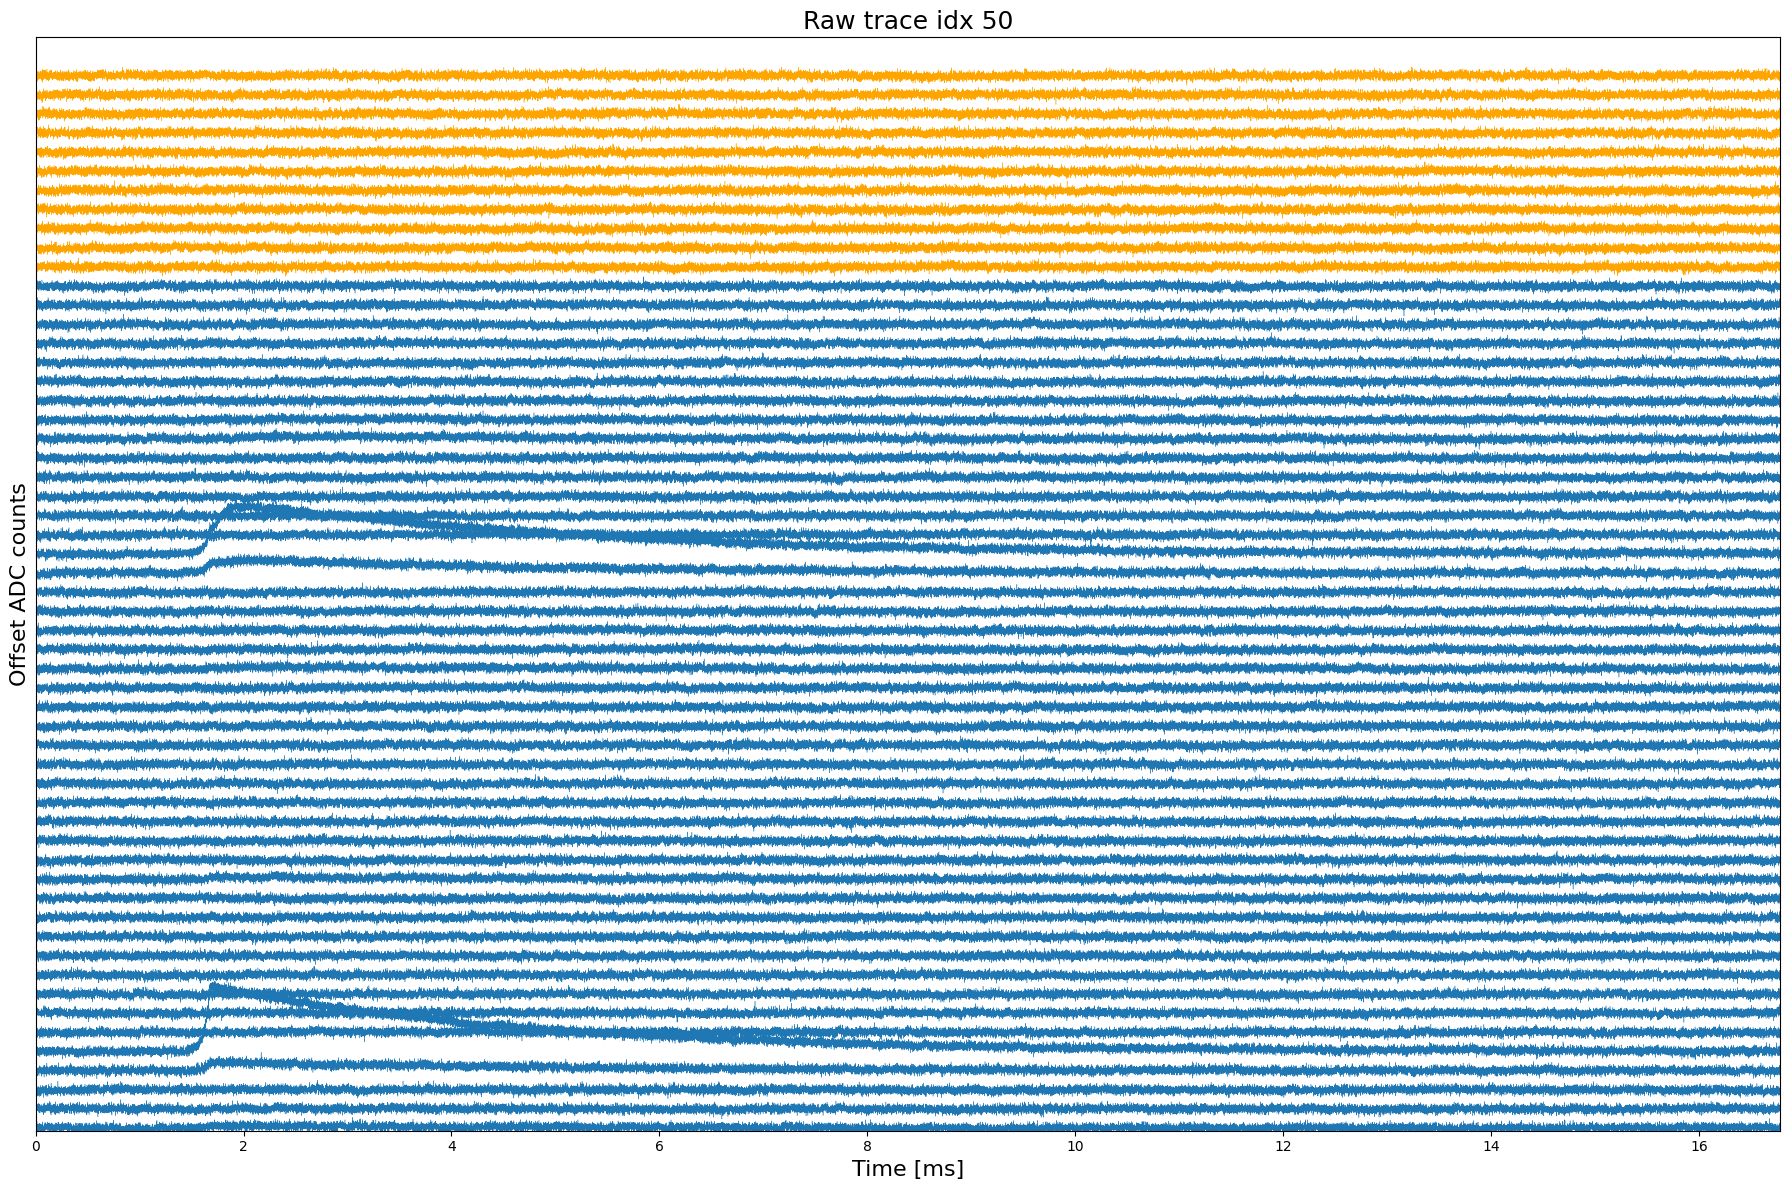

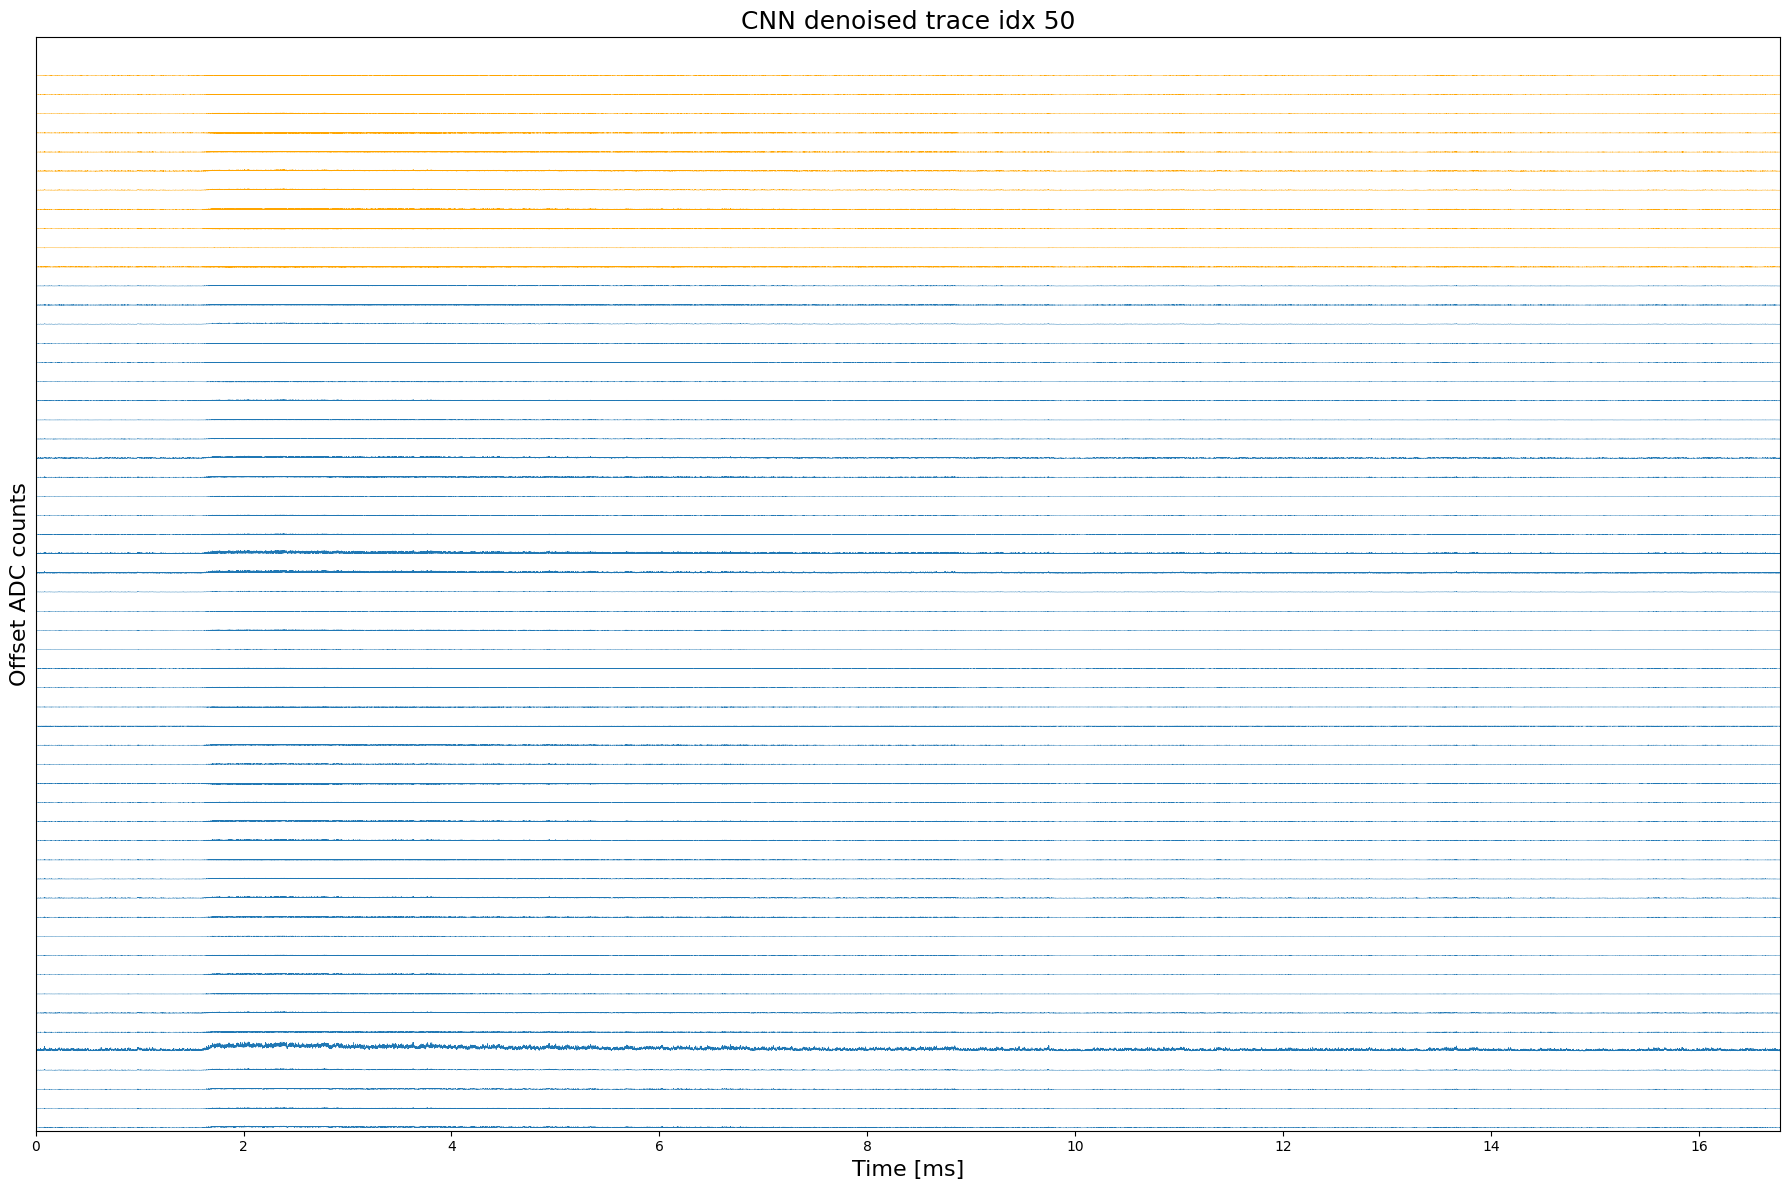

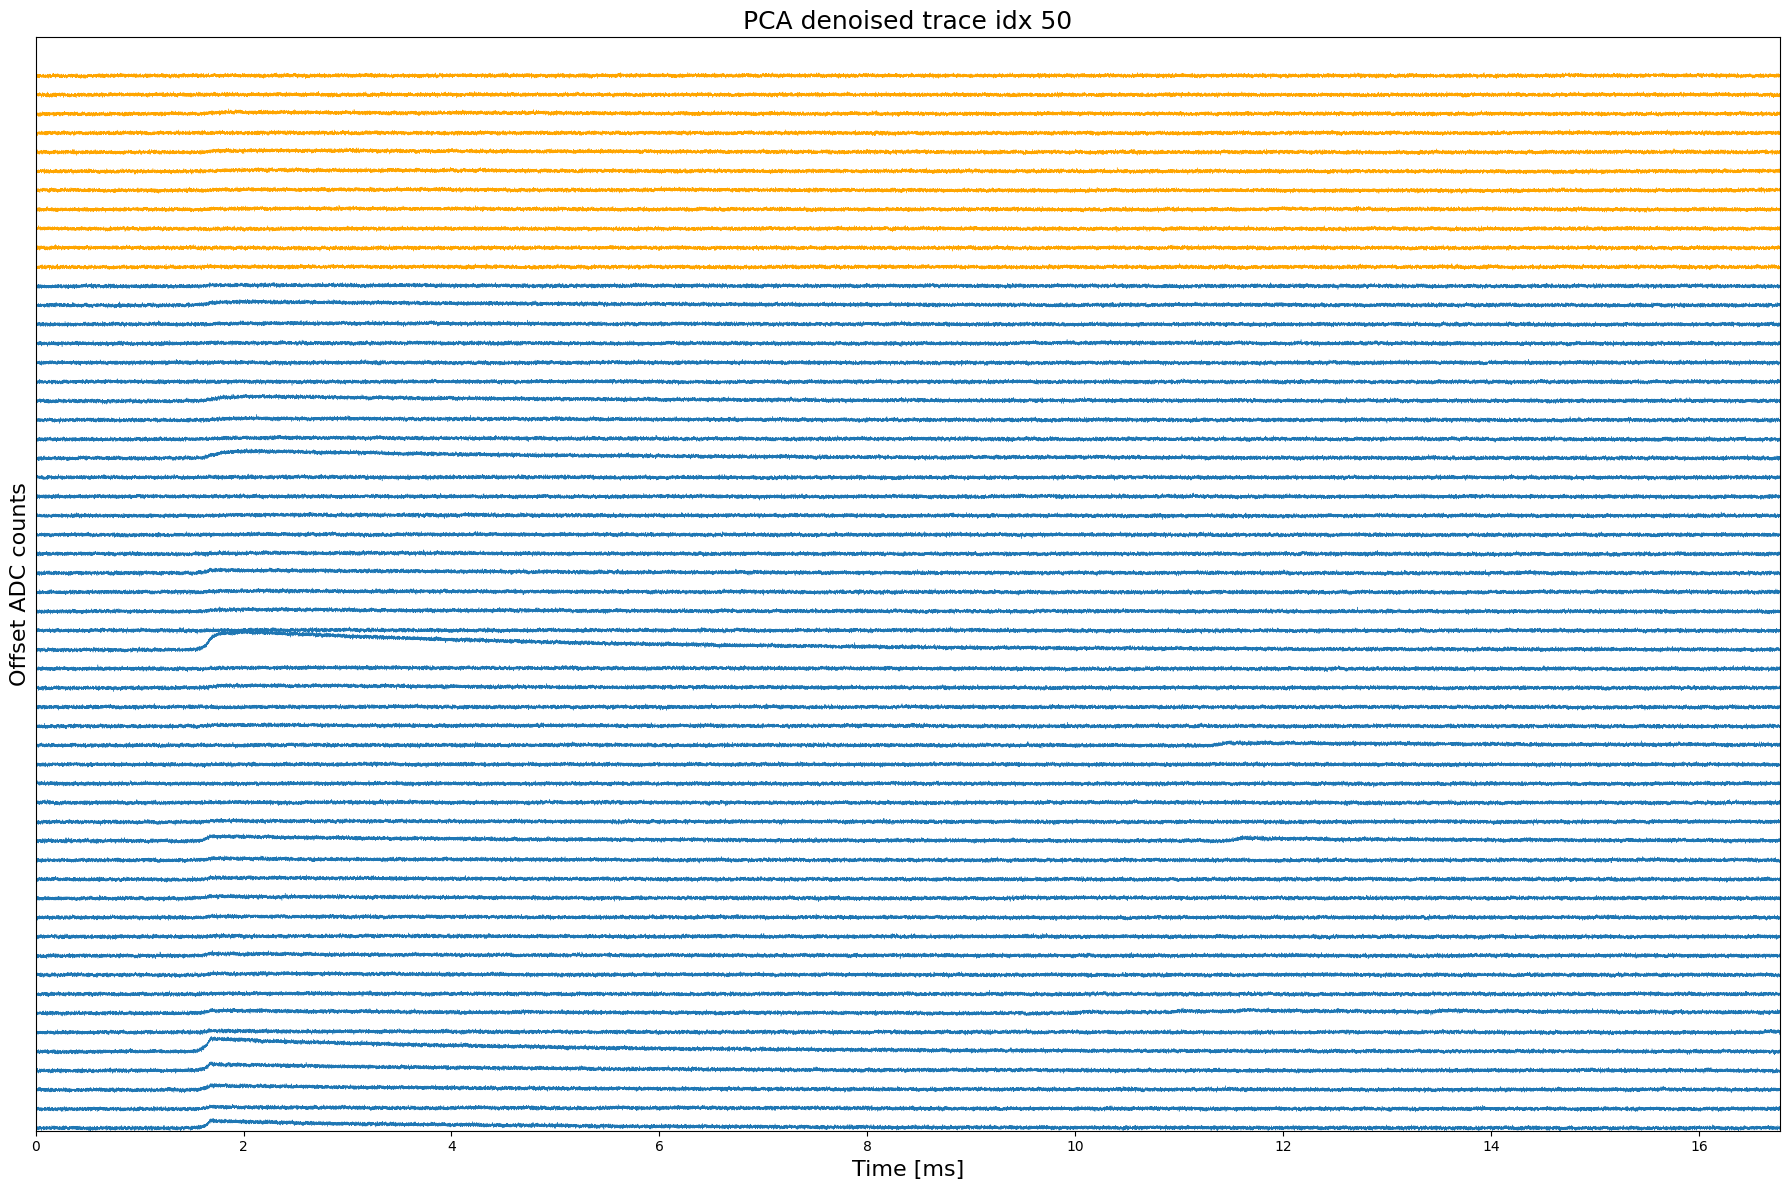

In [16]:
# Denoise full trace for index 50 (all channels, full length)
import h5py
from pathlib import Path
from denoiser import train_cnn_denoiser, run_cnn_denoise, fit_pca, pca_denoise

h5_path = Path("/ceph/srv/dwong/training_samples_h5/ER/ER_traces_energy_500_batch_0240.h5")

with h5py.File(h5_path, "r") as f:
    full_trace = f["traces"][50].astype(np.float32)      # (C, T)
    train_subset = f["traces"][:16].astype(np.float32)    # small subset to keep runtime manageable

print("full trace shape:", full_trace.shape)
print("train subset shape:", train_subset.shape)

# PCA fit on subset and apply to full trace
pca_full = fit_pca(train_subset, n_components=10)
pca_recon, _ = pca_denoise(pca_full, full_trace[None, ...])
pca_recon = pca_recon[0]

# CNN train with synthetic noise (quick demo)
noise_level = 0.05 * float(train_subset.std())
noisy_train = train_subset + noise_level * np.random.standard_normal(train_subset.shape).astype(np.float32)
cnn_model = train_cnn_denoiser(noisy_train, train_subset, num_epochs=2, batch_size=2, device="cpu")
noisy_full = full_trace + noise_level * np.random.standard_normal(full_trace.shape).astype(np.float32)
cnn_recon = run_cnn_denoise(cnn_model, noisy_full[None, ...], batch_size=1, device="cpu")[0]

print("PCA MSE (full trace):", float(np.mean((pca_recon - full_trace) ** 2)))
print("CNN MSE (full trace):", float(np.mean((cnn_recon - full_trace) ** 2)))

plot_traces(full_trace, title="Raw trace idx 50")
plot_traces(cnn_recon, title="CNN denoised trace idx 50")
plot_traces(pca_recon, title="PCA denoised trace idx 50")


In [ ]:
# Train CNN denoiser on paired H5 files (noisy/clean) from wk28_pairs
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import h5py
import numpy as np
from denoiser import CNNDenoiser1D

# -------- Config --------
data_dir = Path("/ceph/srv/dwong/training_samples_h5/wk28_pairs")
max_files = None          # set to an int to subset (e.g., 10) for quick tests
batch_size = 2            # trace length is large; keep batch modest
epochs = 2                # increase for real training
lr = 1e-3
ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / "cnn_denoiser_latest.pt"
final_path = ckpt_dir / "cnn_denoiser_final.pt"
num_workers = 0           # h5py is not fork-safe; keep 0 or 1 unless using spawn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -------- Dataset --------
class H5PairDataset(Dataset):
    def __init__(self, files):
        self.files = list(files)
        self.file_lengths = []
        for fp in self.files:
            with h5py.File(fp, "r") as f:
                self.file_lengths.append(len(f["traces"]))
        self.cum = np.cumsum([0] + self.file_lengths)

    def __len__(self):
        return self.cum[-1]

    def __getitem__(self, idx):
        file_idx = np.searchsorted(self.cum, idx, side="right") - 1
        inner_idx = idx - self.cum[file_idx]
        fp = self.files[file_idx]
        with h5py.File(fp, "r") as f:
            noisy = np.asarray(f["traces"][inner_idx], dtype=np.float32)
            clean = np.asarray(f["traces_clean"][inner_idx], dtype=np.float32)
        return torch.from_numpy(noisy), torch.from_numpy(clean)

all_files = sorted(data_dir.glob("*pair_batch_*.h5"))
if max_files is not None:
    all_files = all_files[:max_files]
print(f"using {len(all_files)} files")
dataset = H5PairDataset(all_files)

# sample shape
sample_noisy, _ = dataset[0]
in_channels = sample_noisy.shape[0]
print("channels:", in_channels, "trace_len:", sample_noisy.shape[-1])

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=(device.type=="cuda"))

# -------- Model / Optimizer --------
model = CNNDenoiser1D(in_channels=in_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.L1Loss()
start_epoch = 0

# optional resume
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    start_epoch = ckpt.get("epoch", 0)
    print(f"Resumed from {ckpt_path} at epoch {start_epoch}")

# -------- Train loop --------
model.train()
for epoch in range(start_epoch, epochs):
    running = 0.0
    for noisy, clean in loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        pred = model(noisy)
        loss = criterion(pred, clean)
        loss.backward()
        optimizer.step()

        running += loss.item() * noisy.size(0)

    epoch_loss = running / len(dataset)
    print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.4e}")

    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "epoch": epoch+1}, ckpt_path)

# -------- Save final model --------
torch.save({"model": model.state_dict(), "in_channels": in_channels}, final_path)
print("saved final model to", final_path)


device: cuda
using 250 files
channels: 56 trace_len: 65536


KeyboardInterrupt: 

: 